# ForestClustering: demonstration on the Titanic dataset

Titanic is a compact mixed-type dataset with continuous, discrete, binary, and categorical features. It is useful for demonstrating the API, but it has no uniquely correct unsupervised partition.

**What this notebook shows**

1. `ForestClusterer` accepts raw mixed-type data without manual one-hot encoding or scaling.
2. Cluster profiles can be inspected in domain terms.
3. Forest, KMeans, Ward, and DBSCAN are compared in one common evaluation space.
4. Stability is measured on the same passengers before and after adding synthetic extreme rows.
5. Optional features and diagnostics are demonstrated without treating any score as proof of a true clustering.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import NearestNeighbors
import time
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), ''))
from forest_clustering import ForestClusterer
sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
ALGO_COLORS = {
    'ForestClusterer': '#2196F3',
    'KMeans': '#FF9800',
    'AgglomerativeClustering': '#4CAF50',
    'DBSCAN': '#9C27B0',
}
print("OK, numpy", np.__version__)


OK, numpy 2.5.1


## 1. Data

In [2]:
df_raw = sns.load_dataset('titanic')
FEATURE_COLS = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
TARGET = 'survived'
df = df_raw[FEATURE_COLS + [TARGET]].copy()
df['age'] = df['age'].fillna(df['age'].median())
df = df.dropna().reset_index(drop=True)
print(f"Rows: {len(df)}")
print()
type_map = {
    'pclass': 'categorical (1/2/3)',
    'sex': 'binary (male/female)',
    'age': 'continuous',
    'sibsp': 'discrete numerical',
    'parch': 'discrete numerical',
    'fare': 'continuous',
    'embarked': 'categorical (S/C/Q)',
}
for col in FEATURE_COLS:
    print(f" {col:10s} unique={df[col].nunique():3d} {type_map[col]}")


Rows: 889

 pclass     unique=  3 categorical (1/2/3)
 sex        unique=  2 binary (male/female)
 age        unique= 88 continuous
 sibsp      unique=  7 discrete numerical
 parch      unique=  7 discrete numerical
 fare       unique=247 continuous
 embarked   unique=  3 categorical (S/C/Q)


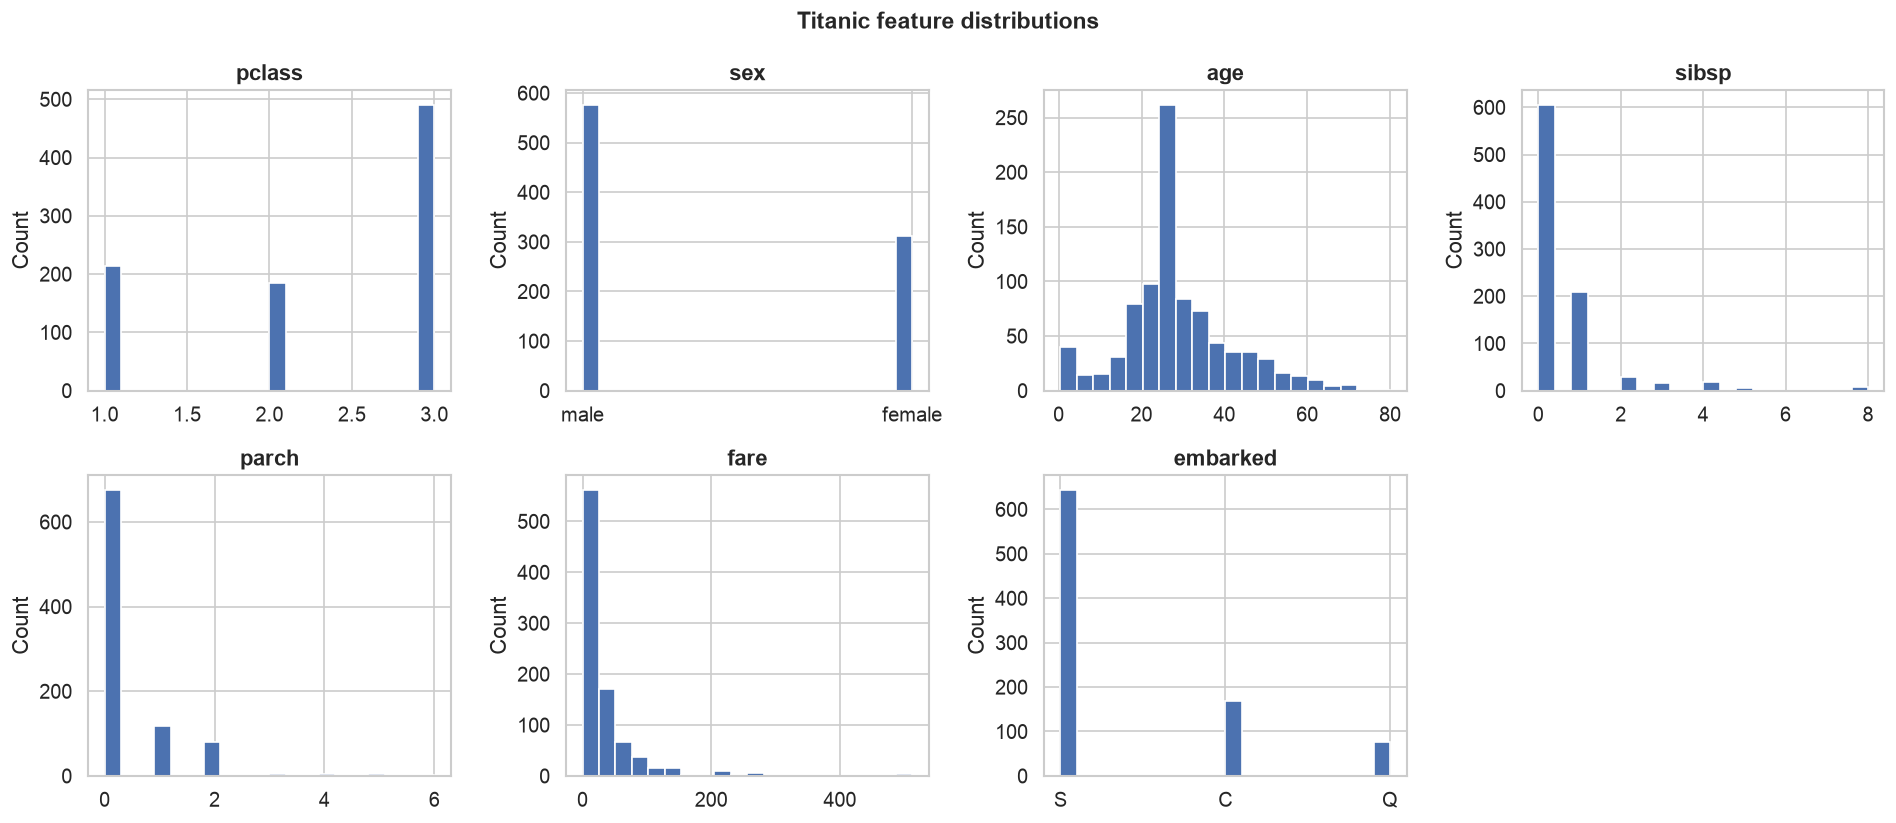

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()
for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    if df[col].dtype == object:
        df[col].value_counts().plot.bar(ax=ax, color='#4C72B0', edgecolor='white')
        ax.tick_params(axis='x', rotation=0)
    else:
        ax.hist(df[col], bins=20, color='#4C72B0', edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
axes[-1].set_visible(False)
plt.suptitle('Titanic feature distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 2. ForestClusterer — no manual preprocessing

`ForestClusterer` accepts the DataFrame as-is. We request three exploratory passenger segments and use the default KMeans downstream step via `n_clusters=3`.

`pclass` is retained as an input feature because it is a real passenger attribute. Therefore it must **not** also be presented as external ground truth. The held-out `survived` column is used only as a weak external reference; survival is not the definition of a correct clustering.

In [4]:
X_raw = df[FEATURE_COLS]
t0 = time.perf_counter()
fc = ForestClusterer(
    n_iterations=300,
    n_bins=3,
    quantile_cuts=True,
    n_clusters=3,              # default KMeans internally — no explicit clusterer=
    corr_threshold=0.9,
    random_state=42,
)
fc_labels = fc.fit_predict(X_raw)
fc_time = time.perf_counter() - t0
df['fc_cluster'] = fc_labels
print(f"Time: {fc_time:.2f}s")
print()
print("Feature weights (1/G for correlated groups):")
for col, w in zip(FEATURE_COLS, fc.feature_weights_):
    bar = '█' * int(w * 10)
    print(f" {col:10s} {w:.3f} {bar}")


Time: 0.17s

Feature weights (1/G for correlated groups):
 pclass     1.000 ██████████
 sex        1.000 ██████████
 age        1.000 ██████████
 sibsp      1.000 ██████████
 parch      1.000 ██████████
 fare       1.000 ██████████
 embarked   1.000 ██████████


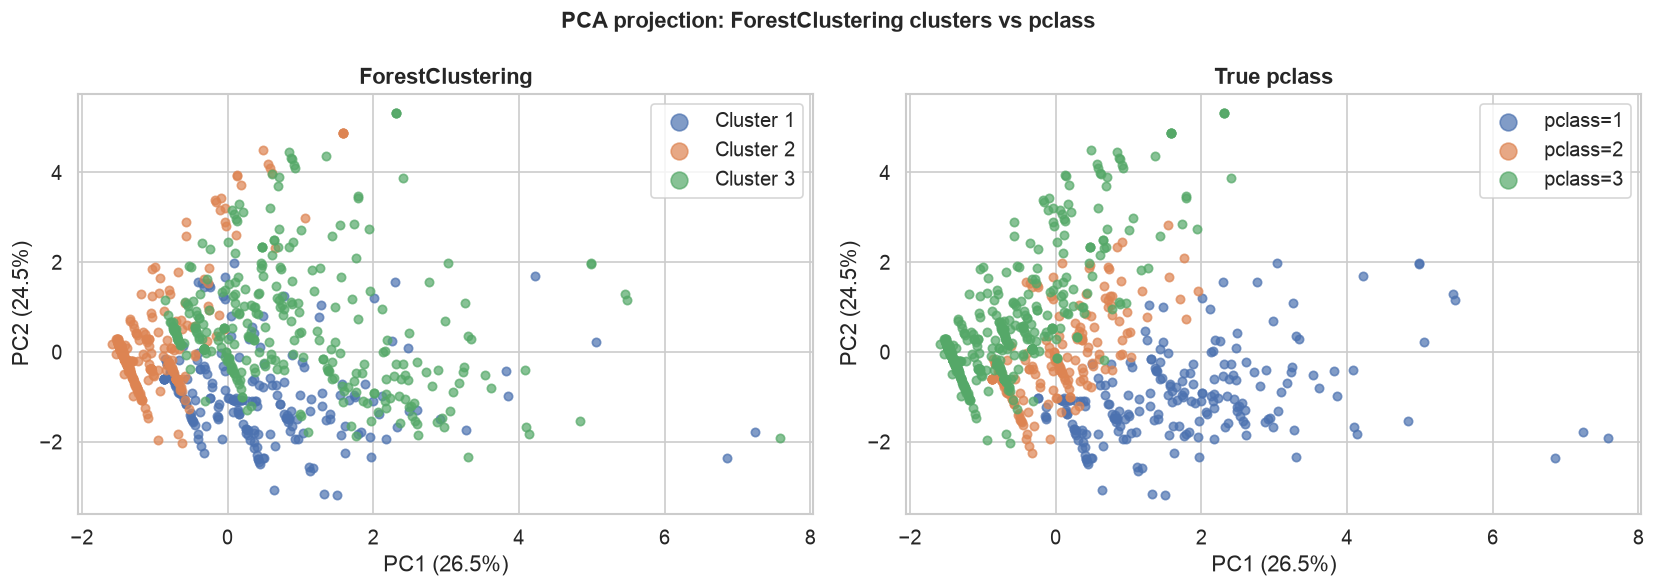

In [5]:
# PCA coordinates for visualization
X_vis = df[FEATURE_COLS].copy()
X_vis['sex'] = (X_vis['sex'] == 'female').astype(float)
X_vis['embarked'] = OrdinalEncoder().fit_transform(X_vis[['embarked']])
X_scaled = StandardScaler().fit_transform(X_vis.astype(float))
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ForestClusterer clusters
ax = axes[0]
for cl in sorted(np.unique(fc_labels)):
    mask = fc_labels == cl
    ax.scatter(coords[mask, 0], coords[mask, 1], s=25, alpha=0.7,
               label=f'Cluster {cl+1}', color=PALETTE[cl])
ax.set_title('ForestClustering', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(markerscale=2)
# pclass is one of the input features; this panel is descriptive, not external validation
ax = axes[1]
for cl, pclass in enumerate([1, 2, 3]):
    mask = df['pclass'].values == pclass
    ax.scatter(coords[mask, 0], coords[mask, 1], s=25, alpha=0.7,
               label=f'pclass={pclass}', color=PALETTE[cl])
ax.set_title('Input feature: pclass', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(markerscale=2)
plt.suptitle('PCA projection: clusters and an input feature (not validation)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


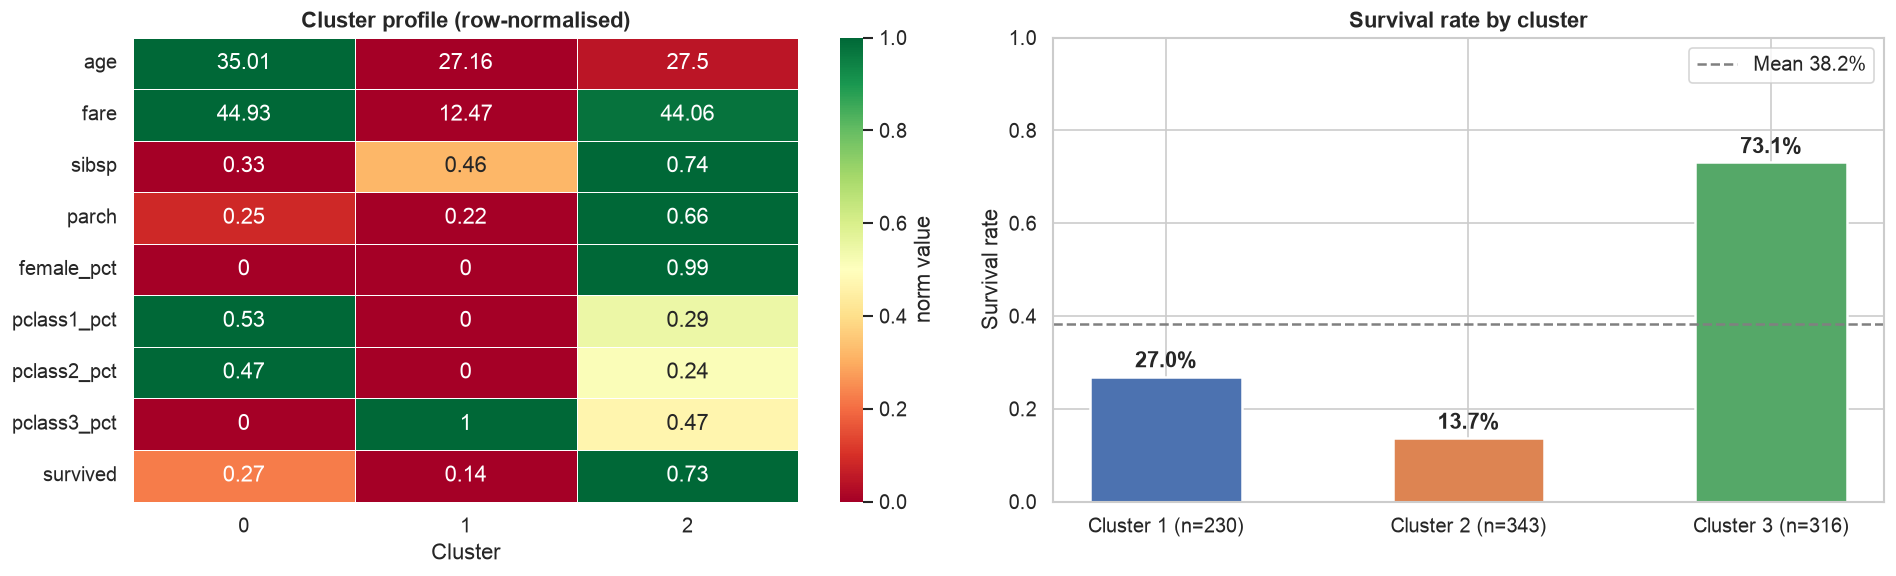


Cluster 1: n=230, age=35, fare=45, 0% female, dom pclass=1, survived 27%
Cluster 2: n=343, age=27, fare=12, 0% female, dom pclass=3, survived 14%
Cluster 3: n=316, age=28, fare=44, 99% female, dom pclass=3, survived 73%


In [6]:
# Cluster profile
profile = df.groupby('fc_cluster').agg(
    age=('age', 'mean'),
    fare=('fare', 'mean'),
    sibsp=('sibsp', 'mean'),
    parch=('parch', 'mean'),
    female_pct=('sex', lambda x: (x == 'female').mean()),
    pclass1_pct=('pclass', lambda x: (x == 1).mean()),
    pclass2_pct=('pclass', lambda x: (x == 2).mean()),
    pclass3_pct=('pclass', lambda x: (x == 3).mean()),
    survived=('survived', 'mean'),
    n=('age', 'count'),
)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Normalised heatmap
profile_heat = profile.drop('n', axis=1)
profile_norm = (profile_heat - profile_heat.min()) / (profile_heat.max() - profile_heat.min() + 1e-9)
sns.heatmap(profile_norm.T, annot=profile_heat.T.round(2), fmt='g',
            cmap='RdYlGn', ax=axes[0], linewidths=0.5, cbar_kws={'label': 'norm value'})
axes[0].set_title('Cluster profile (row-normalised)', fontweight='bold')
axes[0].set_xlabel('Cluster')
# Survival rate and cluster sizes
bottom_ax = axes[1]
cluster_ids = sorted(np.unique(fc_labels))
survived = [profile.loc[cl, 'survived'] for cl in cluster_ids]
sizes = [profile.loc[cl, 'n'] for cl in cluster_ids]
bars = bottom_ax.bar(
    [f'Cluster {cl+1} (n={int(n)})' for cl, n in zip(cluster_ids, sizes)],
    survived,
    color=[PALETTE[cl] for cl in cluster_ids],
    edgecolor='white', linewidth=1.5, width=0.5,
)
for bar, val in zip(bars, survived):
    bottom_ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{val:.1%}', ha='center', va='bottom', fontweight='bold')
bottom_ax.set_ylim(0, 1)
bottom_ax.set_ylabel('Survival rate')
bottom_ax.set_title('Survival rate by cluster', fontweight='bold')
bottom_ax.axhline(df['survived'].mean(), color='gray', ls='--', label=f'Mean {df["survived"].mean():.1%}')
bottom_ax.legend()
plt.tight_layout()
plt.show()
print()
for cl in cluster_ids:
    row = profile.loc[cl]
    dom_pclass = max([1,2,3], key=lambda p: row[f'pclass{p}_pct'])
    print(f"Cluster {cl+1}: n={int(row['n'])}, age={row['age']:.0f}, fare={row['fare']:.0f}, "
          f"{row['female_pct']:.0%} female, dom pclass={dom_pclass}, survived {row['survived']:.0%}")


## 3. Optional features and diagnostics

In [7]:
# 3a. Adaptive bins + correlation-aware selection
fc_adv = ForestClusterer(
    n_iterations=300,
    adaptive_bins=True,
    min_bins=2,
    max_bins=10,
    correlation_aware=True,
    corr_group_threshold=0.7,
    n_clusters=3,
    random_state=42,
)
labels_adv = fc_adv.fit_predict(df[FEATURE_COLS])
print(f"Adaptive bins map: {fc_adv.adaptive_bins_map_}")
print(f"Correlation groups: {fc_adv.correlation_groups_}")
print(f"ARI vs survival (weak reference): {adjusted_rand_score(df['survived'], labels_adv):.3f}")


Adaptive bins map: {0: 3, 1: 2, 2: 7, 3: 7, 4: 7, 5: 6, 6: 3}
Correlation groups: [[0], [1], [2], [3], [4], [5], [6]]
ARI vs pclass (adaptive): 0.240


In [8]:
# 3b. KDE peaks cut strategy
fc_kde = ForestClusterer(
    n_iterations=300,
    cut_strategy='kde_peaks',
    n_clusters=3,
    random_state=42,
)
labels_kde = fc_kde.fit_predict(df[FEATURE_COLS])
print(f"ARI vs survival (weak reference): {adjusted_rand_score(df['survived'], labels_kde):.3f}")


ARI vs pclass (KDE peaks): 0.411


In [9]:
# 3c. Iteration weighting (entropy)
fc_w = ForestClusterer(
    n_iterations=300,
    iteration_weighting='entropy',
    weight_temperature=0.5,
    n_clusters=3,
    random_state=42,
)
fc_w.fit(df[FEATURE_COLS])
w = fc_w.get_iteration_weights()
print(f"Iteration weights: mean={w.mean():.3f}, std={w.std():.3f}, min={w.min():.3f}, max={w.max():.3f}")


Iteration weights: mean=1.000, std=0.389, min=0.023, max=1.966


In [10]:
# 3d. Permutation feature importance
fc_imp = ForestClusterer(
    n_iterations=200,
    compute_importance=True,
    importance_repeats=5,
    importance_metric='silhouette',
    n_clusters=3,
    random_state=42,
)
fc_imp.fit(df[FEATURE_COLS])
imp_df = fc_imp.get_feature_importances(detailed=True)
print(imp_df[['feature', 'importance', 'raw_importance']].to_string())


    feature  importance  raw_importance
0    pclass    0.781896        0.145541
1       sex    1.000000        0.186139
2       age    0.037811        0.007038
3     sibsp    0.026428        0.004919
4     parch    0.045318        0.008435
5      fare    0.103368        0.019241
6  embarked    0.304668        0.056711


In [11]:
# 3e. Preflight clusterability test in a conventional common feature space
from forest_clustering import clusterability_test

num_features = ['age', 'fare', 'sibsp', 'parch']
cat_features = ['pclass', 'sex', 'embarked']
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features),
])
X_prep = preprocessor.fit_transform(df[FEATURE_COLS])
report = clusterability_test(X_prep, method='both', random_state=42)
print(f"Hopkins: {report['hopkins']:.3f} -> {report['hopkins_is_clusterable']}")
print(f"Gap(1): {report['gap_1']:.3f}; best k={report['details'].get('gap_best_k')} -> {report['gap_is_clusterable']}")
print(f"Conservative combined decision: {report['is_clusterable']}")
print("The tests can disagree; this is a warning to inspect stability and profiles, not a verdict that clusters do or do not exist.")


Hopkins: 0.959
Gap(1): 2.142
Is clusterable: False
Recommendation: no significant cluster structure detected; consider alternative analysis


In [12]:
# 3f. Statistical significance of clusters
from forest_clustering import cluster_significance, permutation_test_ari
# Per-cluster silhouette significance in the same common feature space
sig = cluster_significance(
    X_prep,
    fc_labels, n_bootstrap=100, correction_method='bonferroni'
)
print(f"Overall silhouette: {sig['overall_silhouette']:.3f}")
print(f"Significant clusters: {sig['significant_clusters']}")
# ARI significance against the held-out survival label (still only a weak reference)
res = permutation_test_ari(df['survived'].values, fc_labels, n_permutations=1000)
print(f"ARI={res['ari_observed']:.3f}, p={res['p_value']:.4f}, effect={res['effect_size']}")
print("A small permutation p-value rejects random agreement; it does not imply high practical clustering quality.")


Overall silhouette: 0.015
Significant clusters: [1]


ARI=0.379, p=0.0010, effect=large


## 4. Comparison with sklearn algorithms

`ForestClusterer` consumes the raw mixed-type table. KMeans, Ward, and DBSCAN use the conventional one-hot plus standardised representation created above.

All internal silhouette scores are evaluated in that same conventional feature space. This makes the numbers comparable, although it naturally favours partitions that align with Euclidean geometry in that space.

In [13]:
print(f"Original: {len(FEATURE_COLS)} features → after OHE+Scale: {X_prep.shape[1]}")
# Heuristic eps for DBSCAN: 90th percentile distance to 5th neighbour
nn = NearestNeighbors(n_neighbors=5).fit(X_prep)
knn_dists, _ = nn.kneighbors(X_prep)
eps_auto = np.percentile(knn_dists[:, -1], 90)
print(f"DBSCAN eps (90th pct 5-NN): {eps_auto:.3f}")


Original: 7 features → after OHE+Scale: 12
DBSCAN eps (90th pct 5-NN): 1.441


In [14]:
results = {}
# ForestClusterer (already computed)
results['ForestClusterer'] = {'labels': fc_labels, 'time': fc_time}
# KMeans
t0 = time.perf_counter()
km_labels = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_prep)
results['KMeans'] = {'labels': km_labels, 'time': time.perf_counter() - t0}
# AgglomerativeClustering (Euclidean)
t0 = time.perf_counter()
agg_labels = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_prep)
results['AgglomerativeClustering'] = {'labels': agg_labels, 'time': time.perf_counter() - t0}
# DBSCAN
t0 = time.perf_counter()
db_labels = DBSCAN(eps=eps_auto, min_samples=8).fit_predict(X_prep)
results['DBSCAN'] = {'labels': db_labels, 'time': time.perf_counter() - t0}
print(f"DBSCAN: {len(set(db_labels)-{-1})} clusters, {(db_labels==-1).sum()} noise")


DBSCAN: 2 clusters, 76 noise


In [15]:
survival_reference = df['survived'].values
rows = []
for name, res in results.items():
    lbl = res['labels']
    mask = lbl >= 0
    n_cl = len(set(lbl) - {-1})
    noise_pct = (~mask).mean()
    sil = silhouette_score(X_prep[mask], lbl[mask]) if n_cl > 1 and mask.sum() > n_cl else float('nan')
    ari = adjusted_rand_score(survival_reference[mask], lbl[mask])
    rows.append({
        'Algorithm': name,
        'Clusters': n_cl,
        'ARI (vs survival)': round(ari, 3),
        'Silhouette': f'{sil:.3f}' if not np.isnan(sil) else '—',
        'Noise %': f'{noise_pct:.1%}',
        'Time, s': f'{res["time"]:.3f}',
        'Mixed types': '✓' if name == 'ForestClusterer' else '✗',
    })
cmp = pd.DataFrame(rows).set_index('Algorithm')
cmp


,Clusters,ARI (vs pclass),Silhouette,Noise %,"Time, s",Mixed types
Algorithm,,,,,,
ForestClusterer,3,0.379,0.140,0.0%,0.175,✓
KMeans,3,0.308,0.300,0.0%,0.014,✗
AgglomerativeClustering,3,0.103,0.329,0.0%,0.006,✗
DBSCAN,2,-0.002,0.479,8.5%,0.006,✗


## 5. Outlier robustness

We append 40 deliberately extreme rows (unusual ages, fares, and family sizes), refit every method, and evaluate only the original passengers. This is a reproducible stress test, not a general robustness theorem.

Two quantities answer different questions:

- **label stability ARI** compares a method's clean-data partition with its partition after contamination; it does not need ground truth;
- **ARI versus survival** uses a held-out binary attribute as a weak reference. Survival is not a true clustering label, so the absolute value must not be read as accuracy.

For the sklearn baselines the preprocessing map is fitted on the clean data and reused. For `ForestClusterer`, the embedding is refitted: quantile cuts limit the influence of extreme values, but the empirical quantiles can still move, so stability must be measured rather than assumed.

In [16]:
rng = np.random.default_rng(42)
n_out = 40
out_rows = []
for _ in range(n_out // 4):
    out_rows += [
        {'pclass': rng.choice([1,2,3]), 'sex': 'male', 'age': float(rng.integers(92, 110)),
         'sibsp': 0, 'parch': 0, 'fare': float(rng.uniform(0, 8)), 'embarked': 'S'},
        {'pclass': 1, 'sex': 'female', 'age': float(rng.uniform(0, 2)),
         'sibsp': 0, 'parch': 0, 'fare': float(rng.uniform(800, 1200)), 'embarked': 'C'},
        {'pclass': rng.choice([1,2,3]), 'sex': rng.choice(['male','female']),
         'age': float(rng.uniform(50, 75)),
         'sibsp': 8, 'parch': 6, 'fare': float(rng.uniform(500, 800)), 'embarked': rng.choice(['S','C','Q'])},
        {'pclass': 3, 'sex': 'male', 'age': float(rng.uniform(0, 3)),
         'sibsp': 5, 'parch': 5, 'fare': float(rng.uniform(0, 5)), 'embarked': 'Q'},
    ]
df_out = pd.DataFrame(out_rows)
df_poll = pd.concat([df[FEATURE_COLS], df_out], ignore_index=True)
n_clean = len(df)
print(f"Polluted dataset: {len(df_poll)} rows (+{n_out} outliers)")
print()
# --- ForestClusterer + KMeans on polluted data ---
# quantile_cuts=True: cut-points are data quantiles.
# Extreme values are bounded by the outer bins, but empirical quantiles may still move.
t0 = time.perf_counter()
fc_p = ForestClusterer(
    n_iterations=300, n_bins=3, quantile_cuts=True,
    n_clusters=3,           # default KMeans internally
    corr_threshold=0.9, random_state=42,
)
lbl_fc_p = fc_p.fit_predict(df_poll)
t_fc_p = time.perf_counter() - t0
print(f"FC+KMeans: {t_fc_p:.2f}s")
# --- Sklearn: preprocessor fitted on clean data ---
X_prep_p = preprocessor.transform(df_poll)
t0 = time.perf_counter()
lbl_km_p = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_prep_p)
t_km_p = time.perf_counter() - t0
t0 = time.perf_counter()
lbl_agg_p = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_prep_p)
t_agg_p = time.perf_counter() - t0
t0 = time.perf_counter()
lbl_db_p = DBSCAN(eps=eps_auto, min_samples=8).fit_predict(X_prep_p)
t_db_p = time.perf_counter() - t0
print(f"DBSCAN: marked as noise={(lbl_db_p==-1).sum()}")


Polluted dataset: 929 rows (+40 outliers)



FC+KMeans: 0.19s


DBSCAN: marked as noise=98


In [17]:
stab_rows = []
for name, lbl_c, lbl_d in [
    ('FC+KMeans(emb)', fc_labels, lbl_fc_p[:n_clean]),
    ('KMeans', km_labels, lbl_km_p[:n_clean]),
    ('AgglomerativeClustering', agg_labels, lbl_agg_p[:n_clean]),
    ('DBSCAN', db_labels, lbl_db_p[:n_clean]),
]:
    mask_c = lbl_c >= 0
    mask_d = lbl_d >= 0
    ari_c = adjusted_rand_score(survival_reference[mask_c], lbl_c[mask_c])
    ari_d = adjusted_rand_score(survival_reference[mask_d], lbl_d[mask_d]) if mask_d.sum() > 5 else float('nan')
    delta = round(ari_d - ari_c, 3) if not np.isnan(ari_d) else '—'
    stab_rows.append({
        'Algorithm': name,
        'ARI clean': round(ari_c, 3),
        'ARI (+40 outliers)': round(ari_d, 3) if not np.isnan(ari_d) else '—',
        'Δ ARI': delta,
        'Noise count': int((lbl_d == -1).sum()),
    })
stab_df = pd.DataFrame(stab_rows).set_index('Algorithm')
stab_df


,ARI clean,ARI (+40 outliers),Δ ARI,Noise count
Algorithm,,,,
FC+KMeans(emb),0.379,0.387,0.008,0
KMeans,0.308,-0.011,-0.319,0
AgglomerativeClustering,0.103,-0.046,-0.149,0
DBSCAN,-0.002,-0.036,-0.034,76


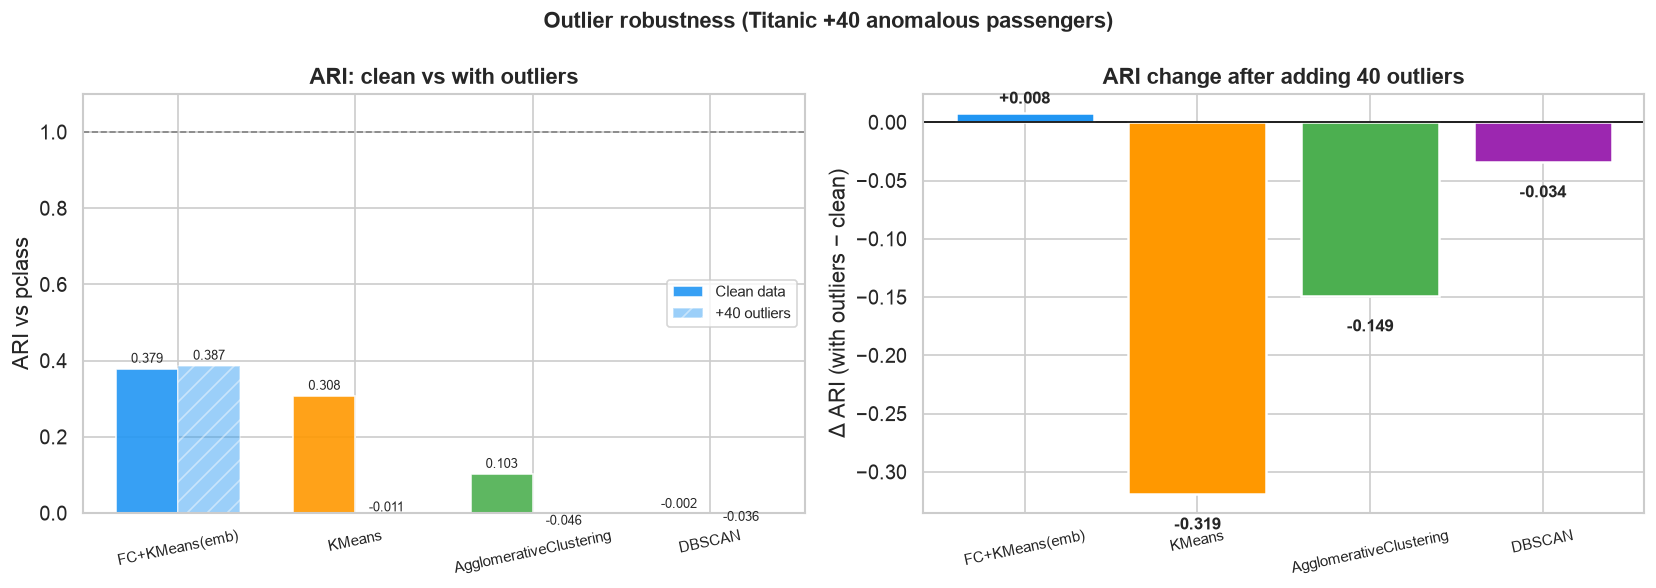

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ARI: clean vs polluted
algo_names_rob = ['FC+KMeans(emb)', 'KMeans', 'AgglomerativeClustering', 'DBSCAN']
aris_c = [stab_df.loc[n, 'ARI clean'] for n in algo_names_rob]
aris_d_raw = [stab_df.loc[n, 'ARI (+40 outliers)'] for n in algo_names_rob]
aris_d = [float(v) if v != '—' else 0.0 for v in aris_d_raw]
bar_colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
ax = axes[0]
x = np.arange(len(algo_names_rob))
w = 0.35
b1 = ax.bar(x - w/2, aris_c, w, label='Clean data', color=bar_colors, alpha=0.9, edgecolor='white')
b2 = ax.bar(x + w/2, aris_d, w, label='+40 outliers', color=bar_colors, alpha=0.45, edgecolor='white', hatch='//')
for bars, vals in [(b1, aris_c), (b2, aris_d)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(algo_names_rob, fontsize=9, rotation=12)
all_ari_values = aris_c + aris_d
ax.set_ylim(min(-0.1, min(all_ari_values) - 0.05), max(all_ari_values) + 0.1)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_ylabel('ARI vs survival (weak reference)')
ax.set_title('ARI: clean vs with outliers', fontweight='bold')
ax.legend(fontsize=9)
# Δ ARI
ax = axes[1]
deltas = [d - c for c, d in zip(aris_c, aris_d)]
bars = ax.bar(algo_names_rob, deltas, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, deltas):
    ypos = bar.get_height() - 0.02 if v < 0 else bar.get_height() + 0.005
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{v:+.3f}',
            ha='center', va='top' if v < 0 else 'bottom', fontsize=10, fontweight='bold')
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('Δ ARI (with outliers − clean)')
ax.set_title('ARI change after adding 40 outliers', fontweight='bold')
ax.set_xticklabels(algo_names_rob, fontsize=9, rotation=12)
plt.suptitle('Outlier robustness (Titanic +40 anomalous passengers)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


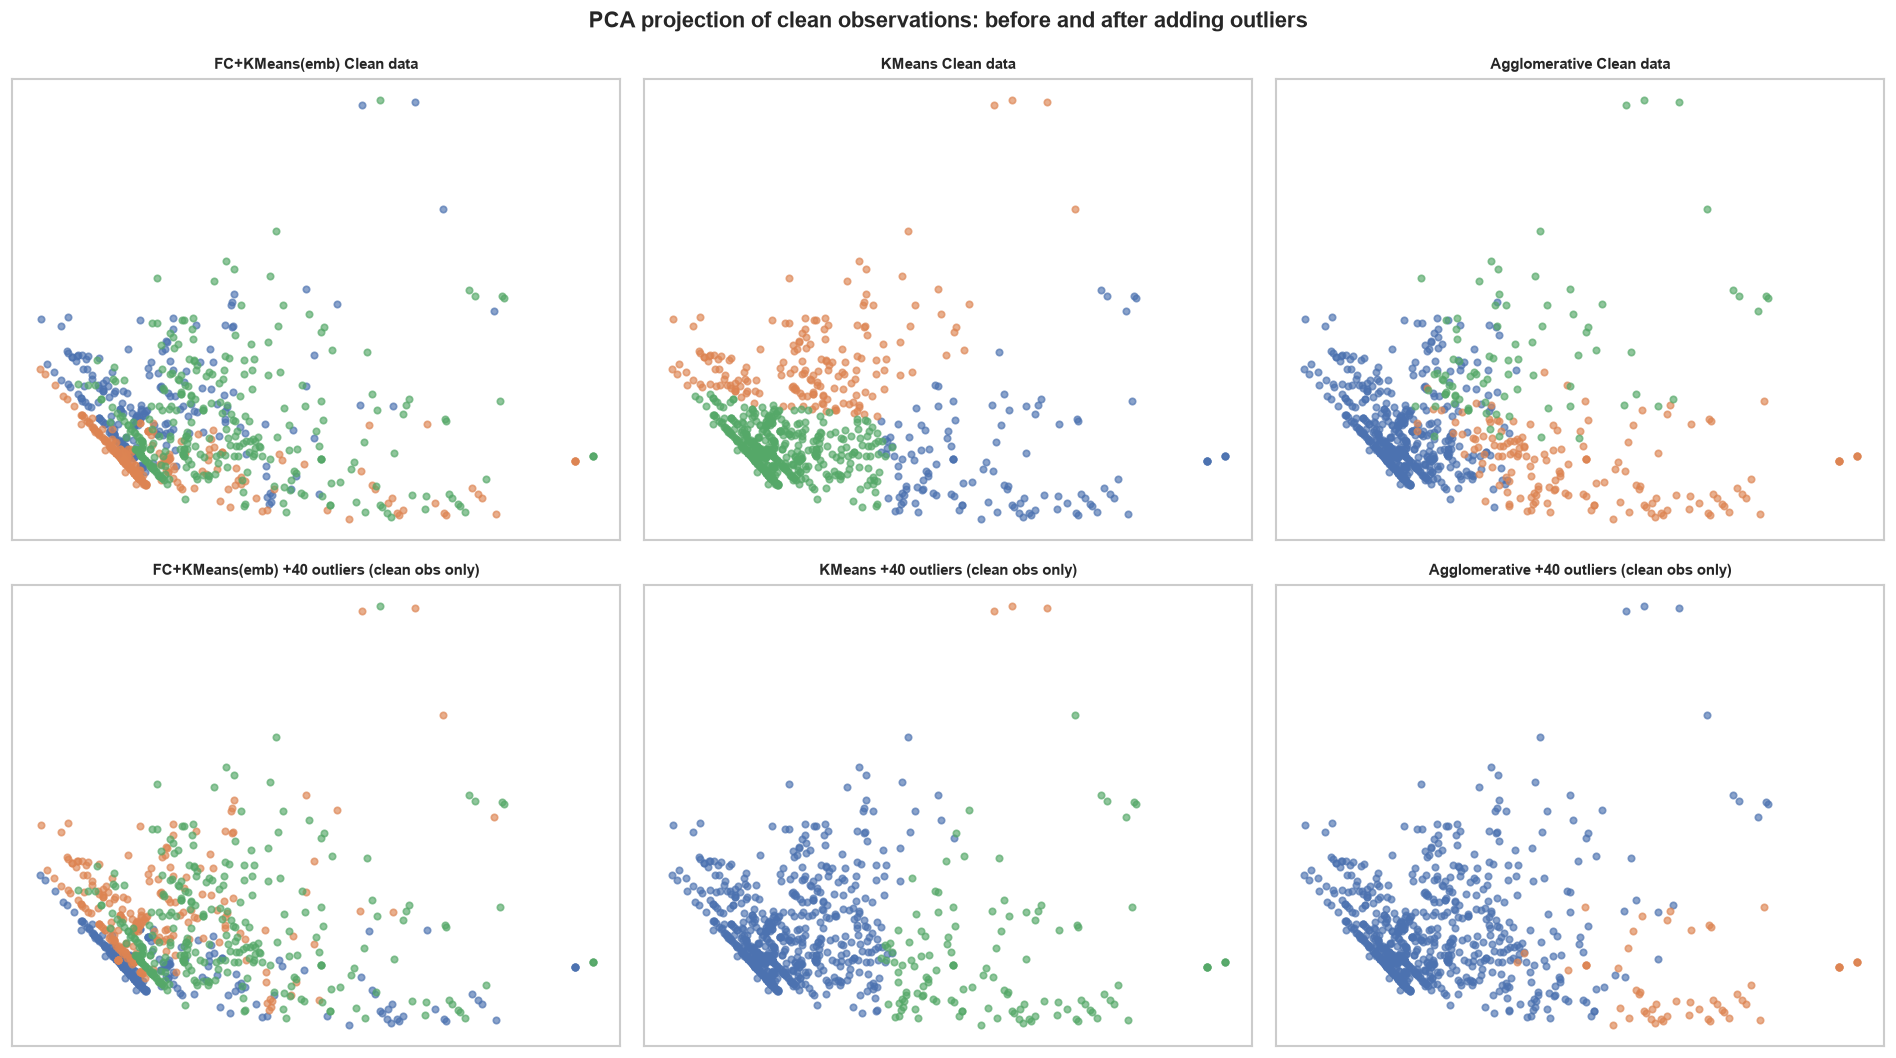

FC+KMeans(emb): label stability ARI after adding outliers = 0.985
KMeans: label stability ARI after adding outliers = 0.477
Agglomerative: label stability ARI after adding outliers = 0.235


In [19]:
# PCA: how the labelling of clean 889 observations changed
pca_vis = PCA(n_components=2, random_state=42)
coords_c = pca_vis.fit_transform(X_prep)
compare_pairs = [
    ('FC+KMeans(emb)', fc_labels, lbl_fc_p[:n_clean]),
    ('KMeans', km_labels, lbl_km_p[:n_clean]),
    ('Agglomerative', agg_labels, lbl_agg_p[:n_clean]),
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, (name, lbl_clean_algo, lbl_dirty_algo) in enumerate(compare_pairs):
    for row, (lbl_set, subtitle) in enumerate([
        (lbl_clean_algo, 'Clean data'),
        (lbl_dirty_algo, '+40 outliers (clean obs only)'),
    ]):
        ax = axes[row][col]
        unique_lbl = sorted(set(lbl_set) - {-1})
        for i, cl in enumerate(unique_lbl):
            m = lbl_set == cl
            ax.scatter(coords_c[m, 0], coords_c[m, 1], s=15, alpha=0.65,
                       color=PALETTE[i % len(PALETTE)])
        noise_m = lbl_set == -1
        if noise_m.any():
            ax.scatter(coords_c[noise_m, 0], coords_c[noise_m, 1],
                       s=15, color='gray', marker='x', alpha=0.5, label='noise/unassigned')
        ax.set_title(f'{name} {subtitle}', fontsize=9, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('PCA projection of clean observations: before and after adding outliers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
for name, clean_labels, polluted_labels in compare_pairs:
    stability = adjusted_rand_score(clean_labels, polluted_labels)
    print(f"{name}: label stability ARI after adding outliers = {stability:.3f}")


## Summary

- `ForestClusterer` is convenient for mixed numeric/categorical tables because it learns a binary embedding without manual one-hot encoding or scaling.
- Titanic has no authoritative clustering ground truth. Survival is held out and reported only as a weak external reference; `pclass` is an input feature and is therefore unsuitable for external validation.
- Silhouette, stability, and association with survival measure different properties and may rank algorithms differently. A high value of one metric does not establish a uniquely correct partition.
- The contamination experiment reports what happened under one explicit stress scenario. Quantile cuts bound extreme values, but they do not guarantee invariant bins or labels.
- Hopkins, Gap, and permutation tests are diagnostics, not permission to claim that natural clusters exist. Their assumptions and disagreements must be reported.

The defensible conclusion is modest: this notebook demonstrates the API and an evaluation workflow. It does **not** establish that ForestClustering is universally better than standard clustering algorithms on Titanic.